

# 1.   Problem Selection:
Fashion Item Classification (Fashion-MNIST)

In [ ]:
from torchvision import datasets
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

from sklearn.preprocessing import StandardScaler
from torch.utils.data import random_split

# **2**. Data:


* preprocessing & normalization and scaling :





In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

*   Data splitting :

In [ ]:
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data', train=False,
    download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)


print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")




Training samples: 60000
Test samples:     10000


In [ ]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    train_dataset, [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 50000 | Val: 10000 | Test: 10000


# 3. Model:
* Multilayer Perceptron (MLP) :

In [ ]:
model = nn.Sequential(
    nn.Flatten(),                  # 28x28 image → 784 numbers
    nn.Linear(784, 256),           # input layer
    nn.ReLU(),
    nn.Linear(256, 128),           # hidden layer 1
    nn.ReLU(),
    nn.Linear(128, 64),            # hidden layer 2
    nn.ReLU(),
    nn.Linear(64, 10)              # output: 10 classes
)

print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=64, bias=True)
  (6): ReLU()
  (7): Linear(in_features=64, out_features=10, bias=True)
)


# 4. Training:

In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Early stopping
best_val_loss = float('inf')
patience = 5
counter = 0
best_model = None

num_epochs = 20

for epoch in range(num_epochs):
   # TRAIN
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        optimizer.zero_grad()           # clear old gradients
        outputs = model(images)         # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()                 # backward pass
        optimizer.step()                # update weights

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
     # VALIDATE
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
     # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch 01/20 | Train Loss: 0.5328 Acc: 0.8053 | Val Loss: 0.4210 Acc: 0.8439
Epoch 02/20 | Train Loss: 0.3869 Acc: 0.8575 | Val Loss: 0.4105 Acc: 0.8496
Epoch 03/20 | Train Loss: 0.3493 Acc: 0.8713 | Val Loss: 0.3376 Acc: 0.8735
Epoch 04/20 | Train Loss: 0.3234 Acc: 0.8799 | Val Loss: 0.3554 Acc: 0.8678
Epoch 05/20 | Train Loss: 0.3023 Acc: 0.8885 | Val Loss: 0.3449 Acc: 0.8763
Epoch 06/20 | Train Loss: 0.2859 Acc: 0.8946 | Val Loss: 0.3384 Acc: 0.8759
Epoch 07/20 | Train Loss: 0.2733 Acc: 0.8987 | Val Loss: 0.2999 Acc: 0.8878
Epoch 08/20 | Train Loss: 0.2598 Acc: 0.9033 | Val Loss: 0.3401 Acc: 0.8759
Epoch 09/20 | Train Loss: 0.2438 Acc: 0.9091 | Val Loss: 0.3123 Acc: 0.8869
Epoch 10/20 | Train Loss: 0.2357 Acc: 0.9128 | Val Loss: 0.3243 Acc: 0.8840
Epoch 11/20 | Train Loss: 0.2246 Acc: 0.9158 | Val Loss: 0.2970 Acc: 0.8940
Epoch 12/20 | Train Loss: 0.2119 Acc: 0.9202 | Val Loss: 0.3073 Acc: 0.8930
Epoch 13/20 | Train Loss: 0.2032 Acc: 0.9233 | Val Loss: 0.3357 Acc: 0.8900
Epoch 14/20 

# 5. Experimentation :

In [ ]:
# EXPERIMENT 2: Tanh
model2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.Tanh(),
    nn.Linear(256, 128),
    nn.Tanh(),
    nn.Linear(128, 64),
    nn.Tanh(),
    nn.Linear(64, 10)
)

criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)

# training
train_losses2, val_losses2 = [], []
train_accs2, val_accs2 = [], []

best_val_loss2 = float('inf')
counter2 = 0
best_model2 = None

for epoch in range(num_epochs):

    model2.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        optimizer2.zero_grad()
        outputs = model2(images)
        loss = criterion2(outputs, labels)
        loss.backward()
        optimizer2.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total
    train_losses2.append(train_loss)
    train_accs2.append(train_acc)

    model2.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model2(images)
            loss = criterion2(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = correct / total
    val_losses2.append(val_loss)
    val_accs2.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss2:
        best_val_loss2 = val_loss
        counter2 = 0
        best_model2 = model2.state_dict()
    else:
        counter2 += 1
        if counter2 >= patience:
            print("Early stopping triggered!")
            break

Epoch 01/20 | Train Loss: 0.5371 Acc: 0.8121 | Val Loss: 0.4456 Acc: 0.8337
Epoch 02/20 | Train Loss: 0.3960 Acc: 0.8564 | Val Loss: 0.3811 Acc: 0.8592
Epoch 03/20 | Train Loss: 0.3602 Acc: 0.8698 | Val Loss: 0.3769 Acc: 0.8614
Epoch 04/20 | Train Loss: 0.3423 Acc: 0.8757 | Val Loss: 0.3589 Acc: 0.8629
Epoch 05/20 | Train Loss: 0.3219 Acc: 0.8823 | Val Loss: 0.3435 Acc: 0.8715
Epoch 06/20 | Train Loss: 0.3125 Acc: 0.8843 | Val Loss: 0.3384 Acc: 0.8760
Epoch 07/20 | Train Loss: 0.3016 Acc: 0.8888 | Val Loss: 0.3407 Acc: 0.8759
Epoch 08/20 | Train Loss: 0.2911 Acc: 0.8939 | Val Loss: 0.3502 Acc: 0.8741
Epoch 09/20 | Train Loss: 0.2806 Acc: 0.8971 | Val Loss: 0.3559 Acc: 0.8738
Epoch 10/20 | Train Loss: 0.2759 Acc: 0.8982 | Val Loss: 0.3334 Acc: 0.8791
Epoch 11/20 | Train Loss: 0.2635 Acc: 0.9035 | Val Loss: 0.3434 Acc: 0.8751
Epoch 12/20 | Train Loss: 0.2649 Acc: 0.9026 | Val Loss: 0.3156 Acc: 0.8839
Epoch 13/20 | Train Loss: 0.2569 Acc: 0.9053 | Val Loss: 0.3292 Acc: 0.8817
Epoch 14/20 

#6. Evaluation :

In [ ]:
def evaluate(mdl, loader, name):
    mdl.eval()
    correct, total = 0, 0
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            outputs = mdl(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    acc = correct / total
    final_loss = total_loss / len(loader)

    print(f"\n── {name} ──")
    print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Final Loss    : {final_loss:.4f}")
    print("\nClassification Report:")
    class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    print(classification_report(all_labels, all_preds, target_names=class_names))
    return acc, final_loss
acc1, loss1 = evaluate(model,  test_loader, "Experiment 1 — ReLU")
acc2, loss2 = evaluate(model2, test_loader, "Experiment 2 — Tanh")


── Experiment 1 — ReLU ──
Test Accuracy : 0.8846 (88.46%)
Final Loss    : 0.3796

Classification Report:
              precision    recall  f1-score   support

     T-shirt       0.84      0.82      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.84      0.75      0.79      1000
       Dress       0.88      0.92      0.90      1000
        Coat       0.78      0.85      0.81      1000
      Sandal       0.95      0.97      0.96      1000
       Shirt       0.70      0.71      0.70      1000
     Sneaker       0.95      0.94      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000


── Experiment 2 — Tanh ──
Test Accuracy : 0.8751 (87.51%)
Final Loss    : 0.3621

Classification Report:
              precision    re

# 7. Visualization :

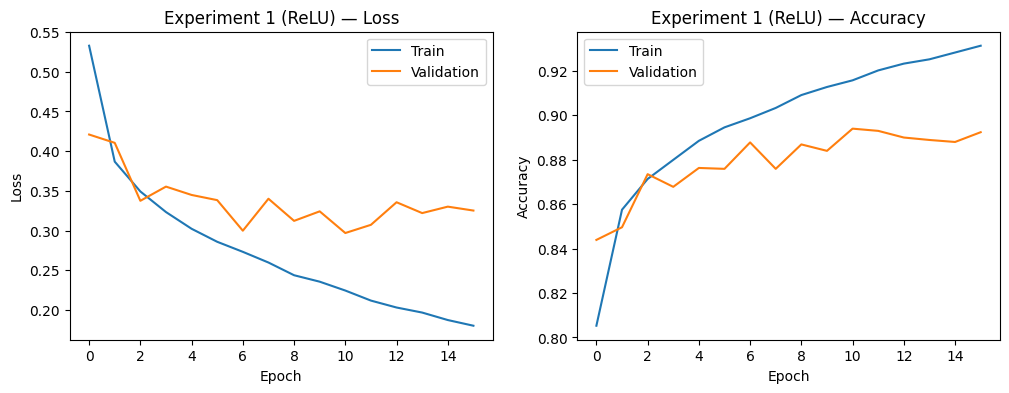

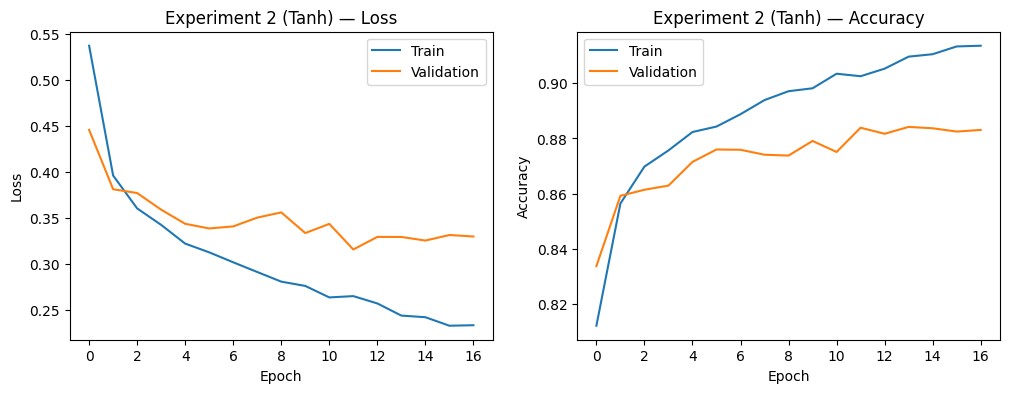

In [ ]:
# Experiment 1: ReLU
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Experiment 1 (ReLU) — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Experiment 1 (ReLU) — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Experiment 2: Tanh
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses2, label="Train")
plt.plot(val_losses2, label="Validation")
plt.title("Experiment 2 (Tanh) — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs2, label="Train")
plt.plot(val_accs2, label="Validation")
plt.title("Experiment 2 (Tanh) — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()